# Bab 6 — Statistical Machine Learning
**Practical Statistics for Data Scientists, 2nd Edition** — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly, 2020)

1. K-Nearest Neighbors (KNN): metrik jarak, one-hot encoding, standardisasi, memilih K, KNN sebagai feature engine
2. Tree models: recursive partitioning, ukuran homogenitas (Gini, entropy), pruning
3. Bagging dan Random Forest: out-of-bag error, variable importance, hyperparameter
4. Boosting (XGBoost): regularisasi, overfitting, hyperparameter tuning dengan cross-validation

In [ ]:
!pip install xgboost

In [ ]:
%matplotlib inline
from itertools import product
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, KFold
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

DATA = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

## Gambaran Besar

Bab-bab sebelumnya fokus pada model statistik klasik (regresi linear, logistic regression) yang punya **bentuk persamaan tertentu**. Bab ini membahas metode yang lebih **data-driven**: model "belajar" pola langsung dari data tanpa mengasumsikan struktur tertentu (**nonparametrik**).

Metode-metode ini dikembangkan oleh komunitas statistik maupun ilmu komputer, dan menjadi dasar banyak model machine learning modern:
- **K-Nearest Neighbors (KNN)** — sangat sederhana: klasifikasikan berdasarkan record yang paling mirip.
- **Tree models** — aturan if-then yang mudah dipahami.
- **Ensemble** — gabungan banyak model: **bagging/random forest** dan **boosting**.

Ensemble berbasis tree (random forest dan boosted trees, misalnya XGBoost) termasuk metode paling kuat dan paling banyak dipakai untuk data tabular.

**Machine learning vs statistik:** batasnya kabur. Secara umum, statistik lebih menekankan **teori probabilitas dan struktur model**, sedangkan machine learning lebih menekankan **akurasi prediksi** dan skalabilitas algoritma.

## 1. K-Nearest Neighbors (KNN)

Ide KNN sangat sederhana. Untuk setiap record yang ingin diklasifikasikan atau diprediksi:
1. Cari **K record** dengan fitur paling mirip (prediktor serupa).
2. **Klasifikasi:** pilih kelas mayoritas di antara tetangga-tetangga itu.
3. **Prediksi numerik (KNN regression):** hitung rata-rata outcome tetangga-tetangga itu.

**Istilah kunci:**
- **Neighbor** — record yang punya nilai prediktor mirip dengan record lain.
- **Distance metrics** — ukuran seberapa jauh dua record satu sama lain.
- **Standardization** — kurangi mean lalu bagi dengan standar deviasi (sinonim: normalisasi).
- **z-score** — nilai hasil standardisasi.
- **k** — jumlah tetangga yang dipakai.

KNN termasuk teknik yang **tidak membangun model** dalam arti biasa. Hasilnya sangat bergantung pada **skala fitur**, **cara mengukur kemiripan**, dan **nilai K**. Semua prediktor harus numerik.

### Contoh kecil: Memprediksi default pinjaman
Data `loan200` berisi 200 pinjaman dengan dua prediktor: `payment_inc_ratio` (rasio cicilan/pendapatan) dan `dti` (*debt-to-income*: rasio utang non-hipotek/pendapatan). Baris pertama adalah pinjaman baru (`target`) yang ingin diprediksi.

In [ ]:
loan200 = pd.read_csv(DATA + 'loan200.csv')

predictors = ['payment_inc_ratio', 'dti']
outcome = 'outcome'

newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
print('Prediksi:', knn.predict(newloan)[0])
print('Probabilitas:', {c: round(float(p), 3) for c, p in zip(knn.classes_, knn.predict_proba(newloan)[0])})

Prediksi: paid off
Probabilitas: {'default': 0.45, 'paid off': 0.55}


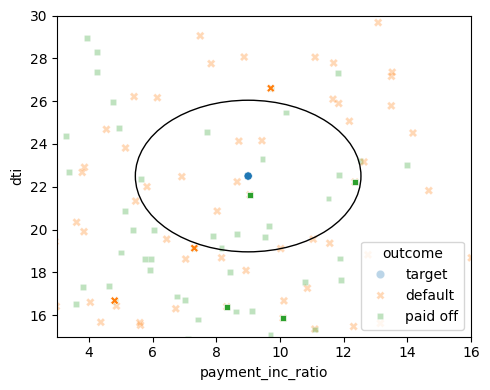

In [ ]:
# Figure 6-2: 20 tetangga terdekat dari pinjaman baru
nclose = X.iloc[knn.kneighbors(newloan, return_distance=False)[0], :]
maxDistance = np.max(knn.kneighbors(newloan)[0][0])

fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', hue='outcome', data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', hue='outcome',
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nclose.index + 1, :]]), ax=ax, legend=False)
ellipse = plt.matplotlib.patches.Ellipse(xy=newloan.values[0], width=2 * maxDistance, height=2 * maxDistance,
                                          edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16); ax.set_ylim(15, 30)
plt.tight_layout(); plt.show()

Di antara 20 tetangga terdekat, 11 lunas dan 9 default, sehingga pinjaman baru diprediksi **paid off** (probabilitas 0,55).

Hasilnya sangat tipis (11 lawan 9). Di buku, versi R memprediksi *default* untuk pinjaman yang sama. Perbedaan seperti ini bisa muncul karena cara software menangani tetangga yang jaraknya sama persis (*ties*). Pelajarannya: untuk kasus di dekat batas 0,5, prediksi KNN tidak stabil, dan probabilitasnya lebih informatif daripada labelnya.

**Catatan:** probabilitas KNN adalah proporsi tetangga. Untuk data seimbang, cutoff 0,5 wajar. Untuk kelas langka, cutoff yang lebih rendah sering lebih masuk akal.

### Metrik Jarak
Kemiripan (*nearness*) diukur dengan **jarak**. Untuk dua record $(x_1, \dots, x_p)$ dan $(u_1, \dots, u_p)$:

**Euclidean distance** (jarak garis lurus, paling umum):
$$\sqrt{(x_1 - u_1)^2 + (x_2 - u_2)^2 + \dots + (x_p - u_p)^2}$$

**Manhattan distance** (jarak "blok kota", menyusuri satu dimensi pada satu waktu):
$$|x_1 - u_1| + |x_2 - u_2| + \dots + |x_p - u_p|$$

**Mahalanobis distance** — memperhitungkan **korelasi** antar variabel. Berguna jika dua variabel sangat berkorelasi, karena tanpa itu, informasi yang sama akan "dihitung dua kali". Kekurangannya: lebih mahal dihitung (perlu matriks kovarians).

### One-Hot Encoder
Data pinjaman sering punya variabel kategorikal. KNN butuh angka, jadi kategori diubah menjadi **dummy biner**. Berbeda dengan regresi (Bab 4), untuk KNN kita biasanya memakai **one-hot encoding penuh** (semua $P$ kategori), karena multikolinearitas tidak menjadi masalah dalam perhitungan jarak.

In [ ]:
loan_data = pd.read_csv(DATA + 'loan_data.csv.gz')
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], categories=['paid off', 'default'], ordered=True)

print(pd.get_dummies(loan_data['home_'], dtype=int).head())

   MORTGAGE  OWN  RENT
0         0    0     1
1         0    1     0
2         0    0     1
3         0    0     1
4         0    0     1


### Standardisasi (Normalisasi, z-score)
Jika satu variabel punya skala jauh lebih besar dari yang lain, variabel itu akan **mendominasi** perhitungan jarak. Solusinya: ubah semua variabel ke skala yang sama dengan **z-score**:
$$z = \frac{x - \bar{x}}{s}$$

**Contoh dari buku:** cari 5 tetangga terdekat untuk satu pinjaman dengan 4 prediktor: `payment_inc_ratio`, `dti`, `revol_bal` (saldo kredit bergulir, dalam dolar), dan `revol_util` (persentase pemakaian kredit).

In [ ]:
predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
print('Pinjaman baru:')
print(newloan)
print('\n5 tetangga terdekat TANPA standardisasi:')
print(X.iloc[nbrs[1][0], :])

Pinjaman baru:
   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4

5 tetangga terdekat TANPA standardisasi:
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


Tanpa standardisasi, nilai `revol_bal` di tetangga-tetangga ini hampir identik dengan pinjaman baru, sedangkan variabel lain sangat bervariasi. Artinya **`revol_bal` mendominasi** perhitungan jarak, karena satuannya dolar (ribuan) sementara variabel lain hanya puluhan.

Sekarang kita standardisasi dulu:

In [ ]:
newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

scaler = preprocessing.StandardScaler()
scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

nbrs = knn.kneighbors(newloan_std)
print('5 tetangga terdekat DENGAN standardisasi:')
print(X.iloc[nbrs[1][0], :])

5 tetangga terdekat DENGAN standardisasi:
       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


Sekarang tetangga-tetangganya jauh lebih mirip di **semua** variabel. Inilah pentingnya standardisasi untuk metode berbasis jarak.

**Catatan penting:** parameter standardisasi (mean dan SD) harus dihitung dari **data latih**, lalu dipakai juga untuk data baru. Itu sebabnya kita `fit` scaler pada `X`, lalu `transform` untuk `newloan`.

### Memilih K
- **K kecil** (misalnya 1) → model sangat sensitif terhadap noise → **overfitting**.
- **K besar** → prediksi terlalu "dihaluskan" → bisa **underfitting** dan kehilangan pola lokal.

Tidak ada nilai K yang selalu terbaik. Biasanya dipilih dengan melihat performa di data **validasi** (holdout atau cross-validation). Nilai yang umum: 1–20, sering dipilih ganjil untuk menghindari seri.

**Bias-variance trade-off:** K kecil → bias rendah, varians tinggi. K besar → bias tinggi, varians rendah.

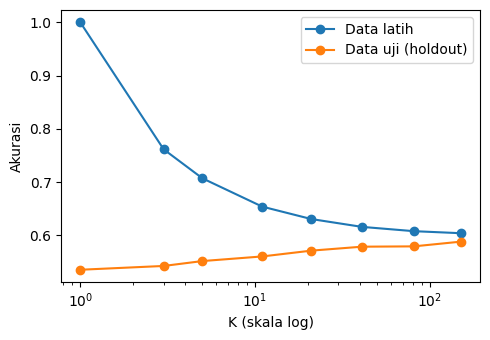

K terbaik di data uji: 151


In [ ]:
# Memilih K dengan holdout set
X_all = loan_data[predictors] * 1.0
y_all = loan_data[outcome]
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=1)
sc = preprocessing.StandardScaler().fit(X_tr)
X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)

ks = [1, 3, 5, 11, 21, 41, 81, 151]
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_tr_s, y_tr)
    train_acc.append(accuracy_score(y_tr, m.predict(X_tr_s)))
    test_acc.append(accuracy_score(y_te, m.predict(X_te_s)))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(ks, train_acc, marker='o', label='Data latih')
ax.plot(ks, test_acc, marker='o', label='Data uji (holdout)')
ax.set_xscale('log'); ax.set_xlabel('K (skala log)'); ax.set_ylabel('Akurasi'); ax.legend()
plt.tight_layout(); plt.show()
print('K terbaik di data uji:', ks[int(np.argmax(test_acc))])

Dengan K = 1, akurasi data latih 100% (setiap titik "tetangga terdekatnya" adalah dirinya sendiri), tapi akurasi data uji paling buruk. Akurasi data uji membaik sampai K cukup besar. Data pinjaman ini sangat "noisy", sehingga K yang besar lebih baik.

### KNN sebagai Feature Engine
KNN jarang menjadi model akhir karena kurang akurat dibanding metode lain dan lambat untuk data besar. Tapi KNN berguna sebagai **pembuat fitur (feature engineering)**:
1. Jalankan KNN pada data dan hasilkan prediksi/probabilitas kelas.
2. Tambahkan hasil itu sebagai **fitur baru** ke model lain.

Ide di balik ini: KNN menangkap informasi **lokal** (kemiripan dengan record lain) yang mungkin tidak tertangkap model global.

**Contoh dari buku:** variabel `borrower_score` yang dipakai di Bab 5 sebenarnya dibuat dengan cara ini! Ia dihasilkan oleh KNN (K = 20) dari beberapa variabel kredit peminjam. Kita bisa mereproduksi idenya:

In [ ]:
predictors = ['dti', 'revol_bal', 'revol_util', 'open_acc', 'delinq_2yrs_zero', 'pub_rec_zero']
outcome = 'outcome'

X = loan_data[predictors] * 1.0
y = loan_data[outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

loan_data['borrower_score_knn'] = knn.predict_proba(X)[:, list(knn.classes_).index('paid off')]
print(loan_data['borrower_score_knn'].describe().round(3))

count    45342.000
mean         0.499
std          0.129
min          0.050
25%          0.400
50%          0.500
75%          0.600
max          1.000
Name: borrower_score_knn, dtype: float64


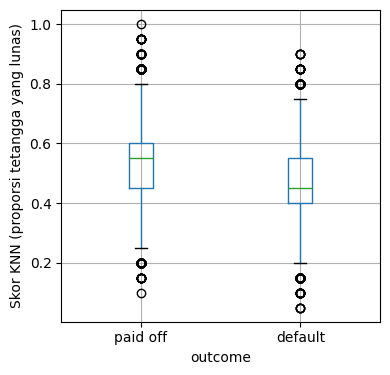

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
loan_data.boxplot(column='borrower_score_knn', by='outcome', ax=ax)
ax.set_ylabel('Skor KNN (proporsi tetangga yang lunas)')
plt.suptitle(''); ax.set_title('')
plt.tight_layout(); plt.show()

Skor KNN (proporsi tetangga yang lunas) lebih tinggi untuk pinjaman yang benar-benar lunas, jadi fitur ini **mengandung informasi** untuk memprediksi outcome dan bisa dipakai sebagai input untuk model lain.

**Hati-hati:** di contoh ini kita menghitung skor pada data yang sama dengan data latih KNN, sehingga skornya sedikit "bocor" (setiap record ikut menjadi tetangganya sendiri). Dalam proyek nyata, fitur seperti ini sebaiknya dibuat dengan cross-validation (*out-of-fold*).

## 2. Tree Models

**Tree models** (disebut juga *Classification and Regression Trees*, **CART**, *decision trees*, atau sekadar *trees*) diperkenalkan oleh Leo Breiman dkk. pada 1984. Tree dan turunannya (random forest, boosted trees) adalah dasar dari model prediktif paling kuat dan populer saat ini.

**Istilah kunci:**
- **Recursive partitioning** — membagi data berulang-ulang dengan tujuan membuat outcome di setiap partisi akhir se-homogen mungkin.
- **Split value** — nilai prediktor yang membagi data menjadi dua bagian (≤ nilai dan > nilai).
- **Node** — satu aturan split; dalam diagram tree, setiap node adalah titik percabangan.
- **Leaf** — ujung dari rangkaian aturan if-then; memberi prediksi akhir untuk record yang sampai ke sana.
- **Loss** — jumlah kesalahan klasifikasi pada suatu tahap; semakin besar, semakin tidak murni (*impure*).
- **Impurity** — seberapa campur kelas-kelas dalam satu partisi (sinonim: heterogenitas; lawannya: homogenitas, purity).
- **Pruning** — memangkas cabang-cabang dari tree yang sudah tumbuh penuh untuk mengurangi overfitting.

**Kenapa populer?**
- Hasilnya berupa **aturan if-then** yang mudah dipahami dan dijelaskan ke orang non-teknis.
- Bisa menangkap **interaksi dan non-linearitas** secara otomatis.
- Tidak perlu standardisasi variabel.

### Contoh: Tree sederhana
Data `loan3000` dengan dua prediktor (`borrower_score` dan `payment_inc_ratio`), seperti di Bab 5.

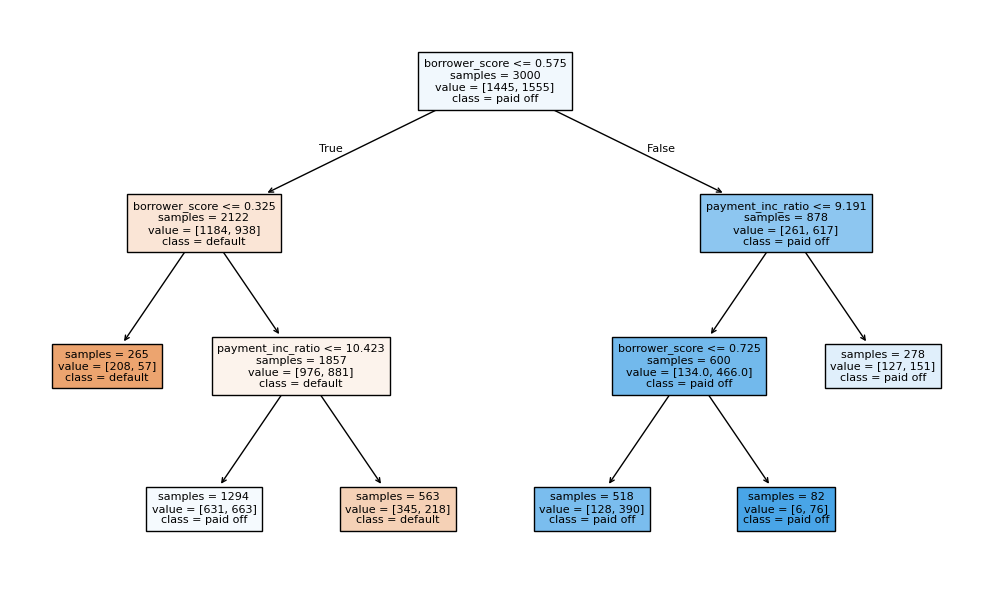

In [ ]:
loan3000 = pd.read_csv(DATA + 'loan3000.csv')
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', min_impurity_decrease=0.003)
loan_tree.fit(X, y)

fig, ax = plt.subplots(figsize=(10, 6))
plot_tree(loan_tree, feature_names=predictors, class_names=loan_tree.classes_, filled=True,
          impurity=False, fontsize=8, ax=ax)
plt.tight_layout(); plt.show()

In [ ]:
# Versi teks aturan if-then
print(export_text(loan_tree, feature_names=predictors))

|--- borrower_score <= 0.58
|   |--- borrower_score <= 0.33
|   |   |--- class: default
|   |--- borrower_score >  0.33
|   |   |--- payment_inc_ratio <= 10.42
|   |   |   |--- class: paid off
|   |   |--- payment_inc_ratio >  10.42
|   |   |   |--- class: default
|--- borrower_score >  0.58
|   |--- payment_inc_ratio <= 9.19
|   |   |--- borrower_score <= 0.72
|   |   |   |--- class: paid off
|   |   |--- borrower_score >  0.72
|   |   |   |--- class: paid off
|   |--- payment_inc_ratio >  9.19
|   |   |--- class: paid off



**Cara membaca:** mulai dari akar (*root*) di atas. Jika `borrower_score` ≤ 0,575, ikuti cabang kiri; jika tidak, cabang kanan. Terus ikuti aturan sampai mencapai **leaf**, yang berisi kelas prediksi (kelas mayoritas di leaf itu).

Probabilitas tiap kelas di sebuah leaf = proporsi record kelas tersebut di leaf itu. Misalnya leaf dengan 300 record di mana 180 lunas → P(lunas) = 0,6.

### Algoritma Recursive Partitioning
Untuk data dengan outcome $Y$ dan prediktor $X_j$:
1. Untuk setiap prediktor $X_j$:
   - Untuk setiap kemungkinan nilai split $s_j$: bagi data menjadi dua (≤ $s_j$ dan > $s_j$), lalu ukur **homogenitas** kelas di tiap bagian.
   - Pilih $s_j$ yang menghasilkan homogenitas terbaik.
2. Pilih prediktor $X_j$ dan split $s_j$ yang **paling baik** di antara semua prediktor.
3. Ulangi secara **rekursif** pada setiap bagian, sampai tidak ada split yang cukup memperbaiki homogenitas.

Hasilnya: ruang prediktor dibagi menjadi **persegi panjang** (*rectangles*), masing-masing dengan prediksi sendiri.

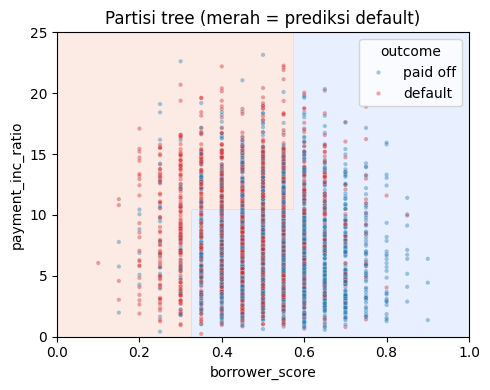

In [ ]:
# Figure 6-4: partisi yang dibuat tree (tiap persegi panjang = satu leaf)
fig, ax = plt.subplots(figsize=(5, 4))
xx, yy = np.meshgrid(np.linspace(0, 1, 300), np.linspace(0, 25, 300))
grid = pd.DataFrame({'borrower_score': xx.ravel(), 'payment_inc_ratio': yy.ravel()})
zz = (loan_tree.predict(grid) == 'default').reshape(xx.shape)
ax.contourf(xx, yy, zz, alpha=0.2, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])
sns.scatterplot(x='borrower_score', y='payment_inc_ratio', hue='outcome', data=loan3000,
                alpha=0.4, s=10, palette={'default': 'C3', 'paid off': 'C0'}, ax=ax)
ax.set_xlim(0, 1); ax.set_ylim(0, 25)
ax.set_title('Partisi tree (merah = prediksi default)')
plt.tight_layout(); plt.show()

### Mengukur Homogenitas (Impurity)
Kita perlu ukuran seberapa "murni" sebuah partisi $A$. Misalkan $p$ = proporsi record yang salah klasifikasi (proporsi kelas minoritas) di partisi itu.

**1. Accuracy (misclassification error):** $p$ itu sendiri. Ternyata kurang bagus untuk memilih split.

**2. Gini impurity:**
$$I(A) = p(1 - p)$$

**3. Entropy (information):**
$$I(A) = -p \log_2(p) - (1-p)\log_2(1-p)$$

Ketiganya bernilai 0 untuk partisi yang murni (hanya satu kelas) dan maksimum pada $p = 0{,}5$ (kelas tercampur rata). Gini dan entropy lebih sensitif terhadap perbaikan kecil dibanding misclassification rate, sehingga lebih baik untuk memilih split.

Untuk split yang membagi data ke dua partisi, homogenitas total adalah **rata-rata berbobot** impurity kedua partisi.

**Hati-hati:** Gini impurity berbeda dari **Gini coefficient** (ukuran ketimpangan ekonomi, terkait AUC). Namanya mirip, konsepnya beda.

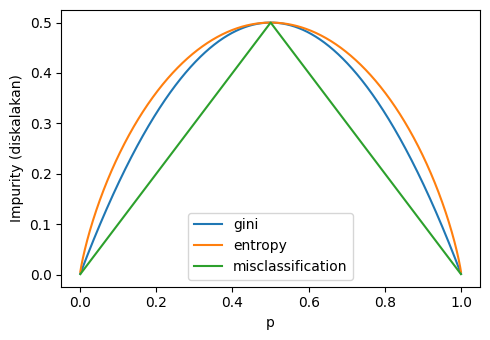

In [ ]:
# Figure 6-5: perbandingan ukuran impurity
p = np.arange(0.001, 1, 0.001)
impure = pd.DataFrame({
    'p': p,
    'gini': p * (1 - p),
    'entropy': -p * np.log2(p) - (1 - p) * np.log2(1 - p),
    'misclassification': np.minimum(p, 1 - p),
})
# Skala supaya puncaknya sama-sama 0,5
impure['gini'] = impure['gini'] / impure['gini'].max() * 0.5
impure['entropy'] = impure['entropy'] / impure['entropy'].max() * 0.5

fig, ax = plt.subplots(figsize=(5, 3.5))
impure.plot(x='p', y=['gini', 'entropy', 'misclassification'], ax=ax)
ax.set_ylabel('Impurity (diskalakan)')
plt.tight_layout(); plt.show()

### Menghentikan Pertumbuhan Tree (dan Pruning)
Jika dibiarkan tumbuh terus, tree akan terus membagi data sampai setiap leaf **murni sempurna**, termasuk mempelajari noise → **overfitting**. Hasilnya bagus di data latih tapi buruk di data baru.

Cara mencegahnya:
- **Batasi pertumbuhan** dengan parameter:
  - `min_samples_split` — jumlah minimum record di node agar boleh di-split.
  - `min_samples_leaf` — jumlah minimum record di setiap leaf.
  - `max_depth` — kedalaman maksimum tree.
  - `min_impurity_decrease` — split hanya dilakukan jika menurunkan impurity minimal sebesar nilai ini.
- **Pruning** — tumbuhkan tree besar, lalu pangkas cabang yang tidak memperbaiki performa di data validasi. Di R, ini diatur lewat *complexity parameter* (`cp`). Di scikit-learn: `ccp_alpha` (*cost-complexity pruning*).

Nilai terbaik untuk parameter ini dipilih dengan **cross-validation**.

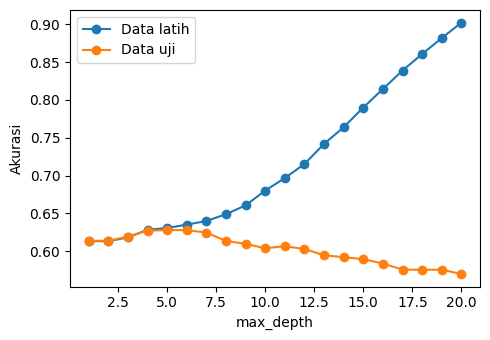

Kedalaman terbaik di data uji: 5


In [ ]:
# Ilustrasi overfitting: kedalaman tree vs akurasi
X_all = loan_data[['borrower_score', 'payment_inc_ratio', 'dti', 'revol_util', 'revol_bal', 'annual_inc']]
y_all = loan_data['outcome']
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=1)

depths = range(1, 21)
tr, te = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=1).fit(X_tr, y_tr)
    tr.append(t.score(X_tr, y_tr)); te.append(t.score(X_te, y_te))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(depths, tr, marker='o', label='Data latih')
ax.plot(depths, te, marker='o', label='Data uji')
ax.set_xlabel('max_depth'); ax.set_ylabel('Akurasi'); ax.legend()
plt.tight_layout(); plt.show()
print('Kedalaman terbaik di data uji:', list(depths)[int(np.argmax(te))])

Semakin dalam tree, akurasi data latih terus naik mendekati 100%, tapi akurasi data uji mencapai puncak di kedalaman kecil lalu **turun**. Ini contoh klasik overfitting.

### Memprediksi Nilai Kontinu (Regression Tree)
Tree juga bisa dipakai untuk outcome numerik (`DecisionTreeRegressor`). Bedanya:
- Impurity diukur dengan **deviasi kuadrat dari rata-rata** di setiap partisi (seperti RMSE).
- Prediksi di setiap leaf adalah **rata-rata** outcome record di leaf tersebut.

### Bagaimana Tree Dipakai
Dua kelebihan utama tree:
1. **Mudah divisualisasikan dan dijelaskan** — cocok untuk menjelaskan pola ke non-teknisi.
2. **Aturan yang jelas** — bisa diterjemahkan langsung menjadi kebijakan bisnis ("jika skor < X dan rasio > Y, tolak pinjaman").

Kelemahan utama: **satu tree** kurang akurat dan tidak stabil (perubahan kecil di data bisa menghasilkan tree yang sangat berbeda). Solusinya: gabungkan **banyak tree** → random forest dan boosting.

## 3. Bagging dan Random Forest

Pada 1907, Francis Galton mengamati lomba menebak berat seekor sapi di pameran. **Rata-rata** tebakan semua orang ternyata sangat dekat dengan berat sebenarnya, lebih akurat daripada tebakan hampir setiap individu. Ini adalah prinsip **wisdom of crowds**.

Prinsip yang sama berlaku untuk model: **menggabungkan banyak model** biasanya menghasilkan prediksi yang lebih baik daripada satu model. Ini disebut **ensemble**.

**Istilah kunci:**
- **Ensemble** — membuat prediksi dengan menggabungkan banyak model.
- **Bagging** — teknik ensemble dengan melatih banyak model pada sampel **bootstrap** dari data (*bootstrap aggregating*).
- **Random forest** — bagging dengan decision tree, ditambah pengambilan sampel **variabel** secara acak di setiap split.
- **Variable importance** — ukuran seberapa penting sebuah prediktor bagi performa model.

### Ensemble Sederhana
1. Bangun model prediktif, catat prediksinya.
2. Ulangi untuk beberapa model lain, pada data yang sama.
3. Untuk setiap record, ambil **rata-rata** (atau voting mayoritas) dari prediksi semua model.

### Bagging
Bagging (Leo Breiman, 1994) mirip ensemble sederhana, tapi semua modelnya **sejenis**, dan setiap model dilatih pada **sampel bootstrap** yang berbeda. Untuk $M$ model dengan $n$ record dan $p$ prediktor:
1. Inisialisasi $M$ (jumlah model) dan $m = 1$.
2. Ambil sampel bootstrap $n'$ record **dengan pengembalian** dari data latih.
3. Latih model pada sampel itu → $\hat{f}_m(X)$.
4. Naikkan $m$, ulangi sampai $m > M$.
5. Prediksi bagging: $\hat{f} = \frac{1}{M}\left(\hat{f}_1(X) + \dots + \hat{f}_M(X)\right)$.

### Random Forest
Random forest menambahkan satu unsur acak lagi: di **setiap split**, tree hanya boleh memilih dari **subset acak variabel** (bukan semua variabel). Biasanya sekitar $\sqrt{p}$ variabel untuk klasifikasi.

**Kenapa ini membantu?** Jika ada satu variabel yang sangat dominan, semua tree dalam bagging biasa akan memakai variabel itu di split pertama, sehingga tree-tree-nya **mirip satu sama lain** (berkorelasi). Merata-ratakan tree yang mirip tidak banyak mengurangi varians. Dengan sampling variabel, tree-tree menjadi lebih **beragam**, sehingga rata-ratanya lebih stabil.

### Out-of-Bag (OOB) Error
Setiap sampel bootstrap rata-rata hanya berisi sekitar **63%** record unik. Sisanya (~37%) disebut **out-of-bag (OOB)**. Record OOB bisa dipakai untuk menguji tree tersebut, seperti holdout set gratis. **OOB error** adalah estimasi error di data baru tanpa perlu memisahkan data uji.

In [ ]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

rf = RandomForestClassifier(n_estimators=500, random_state=1, oob_score=True)
rf.fit(X, y)
print(f'OOB accuracy: {rf.oob_score_:.4f}  (OOB error = {1 - rf.oob_score_:.4f})')

OOB accuracy: 0.5753  (OOB error = 0.4247)


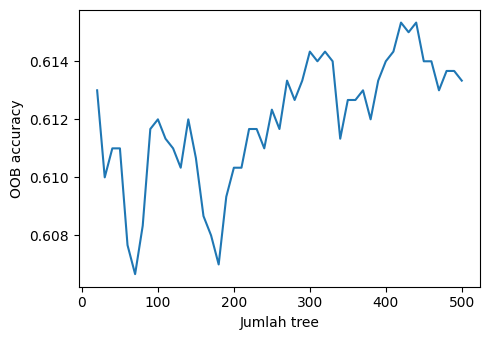

In [ ]:
# Figure 6-6: OOB error vs jumlah tree
n_estimator = list(range(20, 510, 10))
oobScores = []
for n in n_estimator:
    rf_n = RandomForestClassifier(n_estimators=n, criterion='entropy', max_depth=5,
                                  random_state=1, oob_score=True)
    rf_n.fit(X, y)
    oobScores.append(rf_n.oob_score_)

fig, ax = plt.subplots(figsize=(5, 3.5))
pd.DataFrame({'n': n_estimator, 'oobScore': oobScores}).plot(x='n', y='oobScore', ax=ax, legend=False)
ax.set_xlabel('Jumlah tree'); ax.set_ylabel('OOB accuracy')
plt.tight_layout(); plt.show()

Akurasi OOB cepat stabil setelah beberapa puluh tree. Menambah tree lebih banyak tidak menyebabkan overfitting, hanya menambah waktu komputasi.

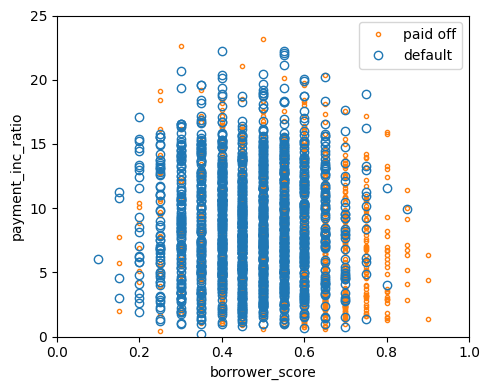

In [ ]:
# Figure 6-7: prediksi random forest pada loan3000
predictions = X.copy()
predictions['prediction'] = rf.predict(X)

fig, ax = plt.subplots(figsize=(5, 4))
predictions.loc[predictions.prediction == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.', markerfacecolor='none', markeredgecolor='C1', ax=ax)
predictions.loc[predictions.prediction == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o', markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default'])
ax.set_xlim(0, 1); ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score'); ax.set_ylabel('payment_inc_ratio')
plt.tight_layout(); plt.show()

Random forest adalah model **"black box"**: prediksinya lebih akurat, tapi aturannya tidak bisa dibaca seperti satu tree. Plot di atas juga menunjukkan prediksi yang "berisik" (titik default dan paid off bercampur di beberapa area), tanda bahwa tanpa batasan, random forest bisa **overfit** data latih.

### Variable Importance
Random forest punya kemampuan penting: mengukur **seberapa penting** setiap prediktor. Ini sangat berguna untuk data dengan banyak fitur.

Dua cara mengukur importance:
1. **Decrease in accuracy (permutation importance)** — acak nilai satu variabel, lalu lihat berapa besar akurasi model **turun**. Semakin besar penurunannya, semakin penting variabel itu. Ini ukuran yang lebih andal.
2. **Mean decrease in Gini impurity** — rata-rata penurunan impurity dari semua split yang memakai variabel tersebut. Cepat dihitung (tersedia di `feature_importances_`), tapi bisa bias terhadap variabel numerik dengan banyak nilai unik.

Contoh: random forest pada data pinjaman lengkap dengan banyak prediktor.

In [ ]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 'payment_inc_ratio', 'revol_bal',
              'revol_util', 'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 'open_acc',
              'grade', 'emp_length', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=1)
rf_all = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=1, n_jobs=-1)
rf_all.fit(X_tr, y_tr)
print(f'Akurasi data uji: {rf_all.score(X_te, y_te):.4f}')

Akurasi data uji: 0.6704


In [ ]:
# Gini importance (cepat) dan permutation importance (lebih andal, dihitung di data uji)
gini_imp = pd.Series(rf_all.feature_importances_, index=X.columns)

perm = permutation_importance(rf_all, X_te.sample(4000, random_state=1),
                              y_te.loc[X_te.sample(4000, random_state=1).index],
                              n_repeats=3, random_state=1, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X.columns)

top = gini_imp.sort_values(ascending=False).head(12).index
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
perm_imp[top].sort_values().plot.barh(ax=axes[0])
axes[0].set_title('Penurunan akurasi (permutation)')
gini_imp[top].sort_values().plot.barh(ax=axes[1])
axes[1].set_title('Penurunan Gini impurity')
plt.tight_layout(); plt.show()

Kedua metode sepakat bahwa **`borrower_score`** adalah prediktor paling penting, dan `grade` juga masuk tiga besar di keduanya. Selebihnya, urutannya cukup berbeda:
- Menurut **permutation importance**, `term_60 months` (pinjaman 60 bulan) sangat penting, sedangkan variabel numerik seperti `revol_util`, `revol_bal`, dan `payment_inc_ratio` hampir tidak berpengaruh (nilainya mendekati nol, bahkan sedikit negatif karena noise).
- Menurut **Gini importance**, variabel numerik kontinu seperti `payment_inc_ratio`, `dti`, dan `revol_util` justru terlihat penting, sementara `term_60 months` ada di bawah.

Ini contoh nyata **bias Gini importance**: variabel numerik dengan banyak nilai unik punya banyak kemungkinan titik split, sehingga sering dipakai tree dan terlihat "penting", padahal kontribusinya terhadap akurasi di data baru kecil. Variabel biner seperti `term` hanya punya satu titik split, sehingga Gini meremehkannya. Karena itu, **ukuran berbasis akurasi (permutation) lebih bisa dipercaya**.

Variable importance berguna untuk:
- memahami data (variabel mana yang benar-benar berpengaruh),
- **seleksi fitur**: membuang variabel yang tidak penting untuk menyederhanakan model.

### Hyperparameter
Random forest adalah salah satu algoritma "**plug and play**": hasil default-nya biasanya sudah cukup baik. Tapi ada beberapa **hyperparameter** yang bisa diatur untuk mengontrol overfitting:
- `min_samples_leaf` — ukuran minimum leaf. Semakin besar, tree semakin sederhana.
- `max_leaf_nodes` — jumlah maksimum leaf per tree.
- `max_features` — jumlah variabel acak yang dipertimbangkan di setiap split.
- `n_estimators` — jumlah tree.

Nilai terbaik dipilih dengan **cross-validation** atau OOB error.

## 4. Boosting

**Boosting** adalah teknik ensemble yang berbeda dari bagging. Alih-alih melatih banyak model secara **independen**, boosting melatih model secara **berurutan**: setiap model baru berfokus memperbaiki **kesalahan** model-model sebelumnya.

**Istilah kunci:**
- **Ensemble** — kumpulan model (sinonim: model averaging).
- **Boosting** — teknik umum untuk melatih serangkaian model, di mana setiap model berikutnya memberi bobot lebih besar pada record yang residualnya besar di model sebelumnya.
- **AdaBoost** — versi awal boosting, berbasis pembobotan ulang data.
- **Gradient boosting** — bentuk boosting yang lebih umum, dirumuskan sebagai minimisasi fungsi biaya (*cost function*).
- **Stochastic gradient boosting** — algoritma boosting paling umum, menambahkan pengambilan sampel acak record dan kolom di setiap iterasi.
- **Regularization** — teknik mencegah overfitting dengan menambahkan penalti terhadap jumlah parameter (kompleksitas) model.
- **Hyperparameters** — parameter yang harus ditentukan sebelum algoritma dijalankan.

### Algoritma Boosting (AdaBoost, versi sederhana)
1. Inisialisasi $M$ (jumlah model), $m = 1$, dan bobot observasi $w_i = 1/N$.
2. Latih model $\hat{f}_m$ dengan bobot $w$, sehingga meminimalkan error berbobot $e_m$.
3. Tambahkan model ke ensemble: $\hat{F}_m = \hat{F}_{m-1} + \alpha_m \hat{f}_m$, dengan $\alpha_m = \log\frac{1 - e_m}{e_m}$.
4. Perbarui bobot $w$ sehingga record yang **salah diklasifikasikan** mendapat bobot **lebih besar**.
5. Naikkan $m$, ulangi dari langkah 2 sampai $m > M$.

**Gradient boosting** merumuskan ide ini secara lebih umum: setiap model baru di-fit ke **gradien** (turunan) dari fungsi loss, yang untuk regresi biasa sama dengan **residual**. Model baru mencoba memprediksi "sisa kesalahan" model sebelumnya.

**Stochastic gradient boosting** menambahkan sampling acak record dan prediktor di setiap tahap, mirip random forest.

### XGBoost
Implementasi boosting paling populer adalah **XGBoost**, dibuat oleh Tianqi Chen dan Carlos Guestrin. Ia sangat cepat, punya banyak opsi, dan sering menjadi pemenang kompetisi data science (misalnya Kaggle).

Dua parameter penting:
- `subsample` — proporsi record yang diambil di setiap iterasi.
- `learning_rate` (atau `eta`) — faktor pengecil untuk $\alpha_m$. Nilai kecil mencegah overfitting tapi butuh lebih banyak iterasi.

**Catatan:** XGBoost butuh outcome numerik (0/1), jadi kita ubah `default` → 1.

In [ ]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = (loan3000[outcome] == 'default').astype(int)

xgb = XGBClassifier(objective='binary:logistic', subsample=0.63, eval_metric='error',
                    n_estimators=100, random_state=1)
xgb.fit(X, y)
print(xgb)

In [ ]:
# Figure 6-9: prediksi XGBoost pada loan3000
xgb_df = X.copy()
xgb_df['prediction'] = ['default' if p == 1 else 'paid off' for p in xgb.predict(X)]
xgb_df['prob_default'] = xgb.predict_proba(X)[:, 1]
print(xgb_df.head())

fig, ax = plt.subplots(figsize=(5, 4))
xgb_df.loc[xgb_df.prediction == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.', markerfacecolor='none', markeredgecolor='C1', ax=ax)
xgb_df.loc[xgb_df.prediction == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o', markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default'])
ax.set_xlim(0, 1); ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score'); ax.set_ylabel('payment_inc_ratio')
plt.tight_layout(); plt.show()

Pola prediksinya mirip random forest: berisik di beberapa area, dengan banyak prediksi default bercampur di wilayah yang mayoritas lunas. Ini tanda bahwa model tanpa batasan cenderung mengikuti noise di data latih.

### Regularisasi: Mencegah Overfitting
Jika dibiarkan tanpa batasan, XGBoost akan **overfit** data latih. Ini bermasalah karena:
1. Akurasi di data baru turun.
2. Prediksi menjadi sangat bervariasi dan tidak stabil.

**Demonstrasi dari buku:** latih XGBoost pada data pinjaman lengkap dengan parameter default, lalu bandingkan dengan model yang diregularisasi.

In [ ]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 'payment_inc_ratio', 'revol_bal',
              'revol_util', 'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 'open_acc', 'grade',
              'emp_length', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000, random_state=1)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1, random_state=1)
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63, random_state=1)
xgb_penalty.fit(train_X, train_y)

for name, m in [('Default (tanpa regularisasi)', xgb_default), ('Penalized (regularisasi)', xgb_penalty)]:
    tr_err = float(np.mean(m.predict(train_X) != train_y))
    va_err = float(np.mean(m.predict(valid_X) != valid_y))
    print(f'{name:30s} error latih = {tr_err:.3f} | error validasi = {va_err:.3f}')

Model tanpa regularisasi punya error latih yang jauh lebih kecil daripada error validasi, tanda jelas **overfitting**. Model yang diregularisasi punya error latih yang lebih tinggi, tapi error validasinya **lebih rendah**: generalisasinya lebih baik.

### Parameter Regularisasi di XGBoost
- `reg_alpha` (**L1 / Manhattan distance**) — penalti berdasarkan jumlah nilai absolut bobot.
- `reg_lambda` (**L2 / Euclidean distance**) — penalti berdasarkan jumlah kuadrat bobot.

Semakin besar nilainya, semakin besar penalti untuk model yang kompleks. Ini sama dengan ide **ridge regression** (L2) dan **lasso** (L1) pada regresi linear.

**Ridge regression** meminimalkan:
$$\sum_{i=1}^{n}(Y_i - b_0 - b_1X_{i1} - \dots - b_pX_{ip})^2 + \lambda(b_1^2 + \dots + b_p^2)$$

**Lasso** memakai $\alpha(|b_1| + \dots + |b_p|)$ sebagai penalti. Lasso bisa membuat beberapa koefisien menjadi **tepat nol** (seleksi fitur otomatis).

### Error vs Jumlah Iterasi
Kita bisa melihat bagaimana error berkembang seiring bertambahnya tree, untuk data latih dan validasi.

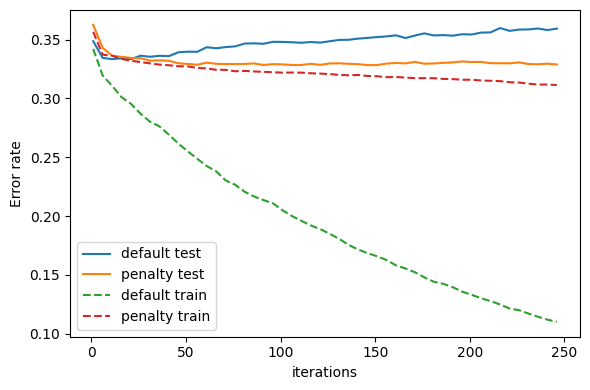

In [ ]:
results = []
for i in range(1, 251, 5):
    train_def = xgb_default.predict(train_X, iteration_range=(0, i))
    valid_def = xgb_default.predict(valid_X, iteration_range=(0, i))
    train_pen = xgb_penalty.predict(train_X, iteration_range=(0, i))
    valid_pen = xgb_penalty.predict(valid_X, iteration_range=(0, i))
    results.append({
        'iterations': i,
        'default train': float(np.mean(train_def != train_y)),
        'default test': float(np.mean(valid_def != valid_y)),
        'penalty train': float(np.mean(train_pen != train_y)),
        'penalty test': float(np.mean(valid_pen != valid_y)),
    })
results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(6, 4))
results.plot(x='iterations', y='default test', ax=ax)
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax, ls='--')
results.plot(x='iterations', y='penalty train', ax=ax, ls='--')
ax.set_ylabel('Error rate')
plt.tight_layout(); plt.show()

- **Default (tanpa regularisasi):** error latih terus turun, tapi error uji naik setelah beberapa puluh iterasi. Model makin "menghafal" data latih.
- **Penalized:** error latih dan uji turun bersama dan tetap berdekatan. Model belajar pola yang lebih umum.

### Hyperparameter dan Cross-Validation
XGBoost punya banyak hyperparameter, dan kombinasinya memengaruhi hasil. Cara sistematis memilihnya: **cross-validation** + **grid search**.

Hyperparameter utama:
| Parameter | Fungsi |
|---|---|
| `learning_rate` (`eta`) | Faktor pengecil (0–1) untuk setiap tree baru. Nilai kecil → lebih tahan overfitting, butuh lebih banyak tree. |
| `n_estimators` | Jumlah iterasi/tree. |
| `max_depth` | Kedalaman maksimum tree. Default XGBoost: 6. Tree dangkal mengurangi overfitting. |
| `subsample` / `colsample_bytree` | Proporsi record / prediktor yang diambil di setiap tree. Mirip random forest. |
| `reg_lambda` / `reg_alpha` | Parameter regularisasi L2 / L1. |

**Contoh dari buku:** uji kombinasi `learning_rate` (0,1; 0,5; 0,9) dan `max_depth` (3; 6; 12) dengan **5-fold cross-validation**. (Di sini dipakai sampel data supaya cepat dijalankan.)

In [ ]:
idx = np.random.default_rng(1).choice(len(X), size=10000, replace=False)
X_cv, y_cv = X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=1)
params = list(product([0.1, 0.5, 0.9], [3, 6, 12]))
error = []
for eta, max_depth in params:
    fold_errors = []
    for train_idx, valid_idx in kf.split(X_cv):
        m = XGBClassifier(objective='binary:logistic', n_estimators=100, reg_lambda=1000,
                          learning_rate=eta, max_depth=max_depth, subsample=0.63, random_state=1)
        m.fit(X_cv.loc[train_idx], y_cv.loc[train_idx])
        fold_errors.append(float(np.mean(m.predict(X_cv.loc[valid_idx]) != y_cv.loc[valid_idx])))
    error.append(fold_errors)

errors = pd.DataFrame({
    'eta': [p[0] for p in params],
    'max_depth': [p[1] for p in params],
    'avg_error': [100 * np.mean(e) for e in error],
})
print(errors.pivot_table(index='eta', columns='max_depth', values='avg_error').round(2))

Hasilnya (rata-rata error dalam persen) menunjukkan bahwa semua kombinasi menghasilkan error yang **sangat mirip**, sekitar 33–34%. Selisih antar kombinasi lebih kecil dari variasi antar fold, jadi tidak ada pemenang yang jelas. Ini wajar karena kita sudah memakai regularisasi kuat (`reg_lambda=1000`) dan `subsample`, yang meredam overfitting di semua kombinasi.

Pelajarannya: hyperparameter tuning **tidak selalu** menghasilkan peningkatan besar. Kalau hasilnya mirip, pilih model yang **lebih sederhana dan lebih cepat** (misalnya `max_depth` kecil dan `learning_rate` kecil), sesuai prinsip Occam's razor dari Bab 4.

**Prinsip umum memilih hyperparameter:**
- Mulai dengan `learning_rate` kecil (0,01–0,1) dan `max_depth` kecil–sedang (3–6).
- Gunakan cross-validation untuk membandingkan kombinasi.
- Perhatikan selisih error latih vs validasi sebagai tanda overfitting.
- Untuk data besar, grid search bisa mahal; *random search* atau *early stopping* sering lebih efisien.

## Ringkasan Bab 6

- **K-Nearest Neighbors (KNN)** mengklasifikasikan record berdasarkan kelas mayoritas K tetangga terdekat. Butuh **metrik jarak** (Euclidean, Manhattan, Mahalanobis), **one-hot encoding**, dan **standardisasi**. K kecil → overfitting, K besar → underfitting. KNN juga berguna sebagai **feature engine** (contohnya `borrower_score`).
- **Decision tree** membagi data secara **rekursif** menjadi partisi yang semakin homogen, diukur dengan **Gini impurity** atau **entropy**. Mudah dipahami (aturan if-then), tapi satu tree mudah **overfit** dan tidak stabil. Kontrol dengan parameter pertumbuhan dan **pruning**.
- **Bagging** melatih banyak model pada sampel **bootstrap** dan merata-ratakan hasilnya. **Random forest** menambahkan sampling **variabel** acak di setiap split, sehingga tree-tree lebih beragam. **OOB error** memberi estimasi error gratis.
- **Variable importance** (permutation atau Gini) menunjukkan prediktor mana yang paling berpengaruh.
- **Boosting** melatih model secara **berurutan**, masing-masing memperbaiki kesalahan model sebelumnya. **XGBoost** adalah implementasi paling populer.
- Boosting mudah overfit; gunakan **regularisasi** (L1/L2, learning rate kecil, subsample, tree dangkal) dan pilih **hyperparameter** dengan **cross-validation**.

Pesan utama: metode ensemble berbasis tree (random forest dan boosting) termasuk model prediktif **paling akurat** untuk data tabular, tapi kekuatannya harus diimbangi dengan **validasi yang hati-hati** untuk menghindari overfitting.